# Chapter 24: Building a Kaggle Portfolio

**How much of a blend's gain is lost, and what does it look like, when a teammate's OOF file is joined by position but is partly out of order?**

The chapter asks teams to agree on sample, class and fold identities and to validate unique IDs, fold membership and join cardinality before stacking. This measures what skipping the ID check costs and why the failure is easy to miss.

*Constructed data. The size of the loss depends on how complementary the two models are and on how many rows are displaced.*

## The experiment

Six constructed binary tasks of 2,000 rows. Model A (logistic regression on six features) and model B (extremely randomized trees on six other features, with nonlinear effects) each produce 5-fold out-of-fold probabilities. Teammate B's file is saved with the control's share of rows shuffled among themselves, a simple stand-in for a file that was partly re-sorted; at 100% almost every row is displaced, as in a file saved in fold order. Each blend is scored by AUC against the labels in the original order: an average of the two probabilities and a cross-validated logistic stack, joined by ID (the file sorted back by its ID column) and joined by position.

In [1]:
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from kaggle_companion.activities._common import clean

SEED = 24
DATASETS = 6          # independent constructed tasks; every estimate is their mean
N_ROWS = 2000


def generate(rng):
    """Two feature groups: A is linear in the first six columns, B is nonlinear in the last six. Each model sees only its own group."""
    X = rng.normal(size=(N_ROWS, 12))
    z = (X[:, :6] @ np.array([0.9, -0.7, 0.6, 0.5, -0.4, 0.3]) + np.sin(1.5 * X[:, 6]) + 0.9 * X[:, 7] * X[:, 8]
         + 0.7 * (X[:, 9] > 0.3) - 0.2)
    return X, (rng.random(N_ROWS) < 1 / (1 + np.exp(-z))).astype(int)


def oof_predictions(model, X, y, seed):
    """Out-of-fold probabilities, one per row, in the original row order (row i is predicted by a model that never saw row i)."""
    p = np.zeros(len(y))
    for fit, val in StratifiedKFold(5, shuffle=True, random_state=seed).split(X, y):
        p[val] = model.fit(X[fit], y[fit]).predict_proba(X[val])[:, 1]
    return p


def logit(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return np.log(p / (1 - p))


def saved_order(rng, fraction):
    """The order a teammate's file is saved in: `fraction` of the rows are shuffled among themselves, the rest stay in place."""
    order = np.arange(N_ROWS)
    moved = rng.choice(N_ROWS, int(round(fraction * N_ROWS)), replace=False)
    order[moved] = rng.permutation(moved)
    return order


def stacked_auc(p_a, p_b, y):
    """Cross-validated logistic-regression stack of the two logit-transformed columns."""
    features = np.column_stack([logit(p_a), logit(p_b)])
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    return roc_auc_score(y, cross_val_predict(LogisticRegression(), features, y, cv=cv, method="predict_proba")[:, 1])


def one_dataset(fraction, seed):
    rng = np.random.default_rng(seed)
    X, y = generate(rng)
    p_a = oof_predictions(LogisticRegression(max_iter=500), X[:, :6], y, 1)
    p_b = oof_predictions(ExtraTreesClassifier(100, min_samples_leaf=3, random_state=0, n_jobs=1), X[:, 6:], y, 2)
    order = saved_order(rng, fraction)
    # The file as saved: row k of the file holds the prediction for row order[k]. A join by ID undoes that; a join by position does not.
    ids_b = order
    p_b_file = p_b[order]
    by_id = np.empty(N_ROWS)
    by_id[ids_b] = p_b_file                      # sort the file back by its ID column
    assert np.allclose(by_id, p_b)
    return {"a": roc_auc_score(y, p_a), "b_by_id": roc_auc_score(y, by_id), "b_by_position": roc_auc_score(y, p_b_file),
            "blend_by_id": roc_auc_score(y, p_a + by_id), "stack_by_id": stacked_auc(p_a, by_id, y),
            "blend_by_position": roc_auc_score(y, p_a + p_b_file), "stack_by_position": stacked_auc(p_a, p_b_file, y),
            "ids_matching": float(np.mean(ids_b == np.arange(N_ROWS)))}


def run(misaligned_fraction):
    sets = [one_dataset(misaligned_fraction, SEED * 1000 + i) for i in range(DATASETS)]
    mean = {k: float(np.mean([s[k] for s in sets])) for k in sets[0]}
    mean["blend_by_position_per_dataset"] = [s["blend_by_position"] for s in sets]
    return clean({"misaligned_fraction": misaligned_fraction, "rows": N_ROWS, "datasets": DATASETS, **mean,
                  "rows_out_of_place": int(round(misaligned_fraction * N_ROWS))})


## Measure it across the control

The control is **share of the teammate's rows saved out of order**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch24 import explain

VALUES = [0, 0.05, 0.25, 1.0]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                  0   0.05   0.25    1.0
Blend by ID                   0.813  0.813  0.813  0.813
Average blend by position     0.813  0.810  0.798  0.750
Model A alone                 0.771  0.771  0.771  0.771
Teammate B alone, file order  0.660  0.653  0.622  0.502
Positions matching their IDs   100%    95%    75%     0%


## Look at it

The figure shows the default setting, share of the teammate's rows saved out of order = 0.25.

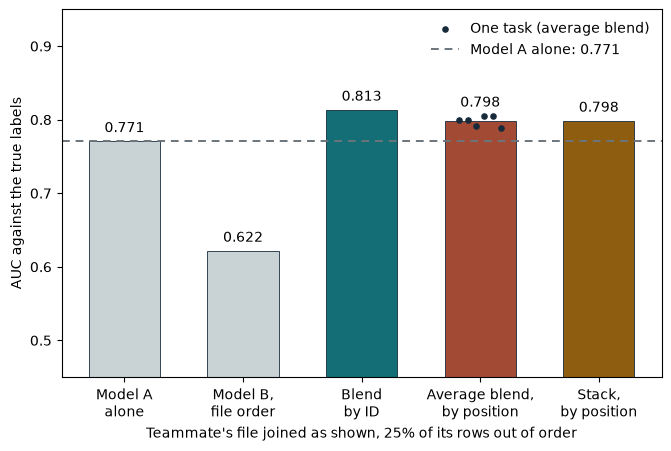

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch24 import draw, NCOLS, HEIGHT

DEFAULT = 0.25
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 500 of 2000 rows out of order (25%), the blend joined by ID scores 0.813, model A alone 0.771, and the blend joined by position 0.798: 0.813 - 0.798 = 0.015 of AUC lost, 35% of the 0.043 the blend gains over model A. The teammate's model scores 0.622 alone in file order against 0.660 by ID, and the stacked blend by position scores 0.798 against 0.818 by ID. Only 75% of positions match their IDs, which an ID check would have reported.

- Blend by ID: 0.813; model A alone: 0.771; gain 0.813 - 0.771 = 0.043.
- Average blend by position: 0.798; lost 0.813 - 0.798 = 0.015.
- Stack by position: 0.798 against 0.818 by ID.
- Teammate B alone: 0.622 in file order, 0.660 by ID.

## Apply this to your competition

- Agree before the team starts on one OOF file format: sample ID, fold, true label, one probability column per class in a stated order.
- Before blending, assert that IDs are unique, complete and equal across files; join by ID and check the join is one to one.
- Score each teammate's file alone as soon as it arrives: a model that scores near chance, or below its owner's own report, signals misalignment first.
- Keep the fold assignments with the predictions, so the OOF provenance can be checked and the blend repeated.

Book location: Chapter 24, Solo or Team.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)